In [ ]:
!pip install transformers
!pip install gensim==4.3.2

In [ ]:
!pip install scipy==1.9.3
!pip install tabulate


In [ ]:
#Import Libraries

#utilities
import random, os, re, multiprocessing, nltk, gc
from tabulate import tabulate
from tqdm import tqdm
import time

#Processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

#Document/Word Vectorization
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from gensim.utils import simple_preprocess

#Modelling
import tensorflow as tf, torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, Dropout, Bidirectional
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
from torch.optim import AdamW
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertForSequenceClassification as BertClassifier, get_linear_schedule_with_warmup

In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

#other setups
bert = 'bert-base-uncased'
start_time = time.time()

In [ ]:
df = pd.read_csv('/content/AI_Human.csv',nrows=10000)
df1




,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0
...,...,...
9995,This argument of the face on Mars been going o...,0.0
9996,"What happen on Mars. In May 24, 2001. One of o...",0.0
9997,"The face on Mars wasn't created by aliens, in ...",0.0
9998,"40 years ago, on mars, NASA caught a picture o...",0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   text       10000 non-null  object 
 1   generated  10000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 156.4+ KB


In [ ]:
#Function for processing and etc
#Preprocessing each text
def text_preprocessing(text):
  #1.cleaning
# Replace hyphens with spaces (optional, if you want to split hyphenated words)
  text = text.replace('-', ' ')

  # Remove URLs and emails
  text = re.sub(r"http\S+|www\S+|\S+@\S+", '', text)

  # Remove content within brackets, parentheses, and braces
  text = re.sub(r'\[.*?\]|\(.*?\)|\{.*?\}', '', text)

  # Replace slashes between words with "atau"
  text = re.sub(r'\b([a-zA-Z]+)\/([a-zA-Z]+)\b', r'\1 or \2', text)

  # Remove mentions (@user) and hashtags (#tag)
  text = re.sub(r'[@#][A-Za-z0-9_]+', '', text)

  # Remove everything that's not alphabet or whitespace
  text = re.sub(r'[^a-zA-Z\s]', '', text)

  # Collapse multiple spaces and strip leading/trailing space
  text = re.sub(r'\s+', ' ', text).strip()

  # text = text.replace('-', ' ')
  # text = re.sub(r'[\r\xa0\t]', '', text)
  # text = re.sub(r"http\S+|www\S+", '', text)
  # text = re.sub(r'\b\w*\.com\w*\b', '', text)
  # text = re.sub(r'\[.*?\]|\(.*?\}|\{.*?\}', '', text)
  # text = re.sub(r'\b(\w+)/(\w+)\b', r'\1 or \2', text)
  # text = re.sub(r'@[A-Za-z0-9]+|#[A-Za-z0-9]+', '', text)
  # text = re.sub(r'[^\w\s]', '', text)
  # text = re.sub(r'\s+', ' ', text)
  # text = text.replace('\n', ' ')
  # text = text.strip(' ')
  # text = re.sub(r'[^a-zA-Z\s]', '', text)
  #2.case folding
  text = text.lower()
  return text

#Preprocessing each docs
def data_preprocessing(data):
  data['text'] = data['text'].apply(lambda _: text_preprocessing(str(_)))
  return data

#Construct tagged data
def construct_tagged_document(X, y):
  tagged_data = [TaggedDocument(words=simple_preprocess(d), tags=[y[i], X.index[i]]) for i, d in enumerate(X)]
  return tagged_data

#Get vector data from model d2v
def d2v_vector(d2v, data_tagged):
  #unpacking tags and infer a vector
  labels, features = zip(*[(doc.tags[0], d2v.infer_vector(doc.words, epochs=20)) for doc in data_tagged])
  features = np.array(features)
  return features, labels

#reshape features & labels for neural network
def transform_data(features, labels):
  features = np.reshape(features, (features.shape[0], features.shape[1], 1))
  labels = np.array(labels).reshape((-1,1))
  return features, labels

#encode data with Bert Tokenizer
def encoded_data(tokenizer, data):
  return tokenizer.batch_encode_plus(
    data,
    add_special_tokens=True,
    return_attention_mask=True,
    padding=True,
    return_tensors='pt'
  )

def clean_memory():
  torch.cuda.empty_cache()
  gc.collect()

In [ ]:
#preprocessing
data = df.copy()
data = data_preprocessing(data)
print(f'shape: {data.shape}')
data

shape: (10000, 2)


,text,generated
0,cars cars have been around since they became f...,0.0
1,transportation is a large necessity in most co...,0.0
2,americas love affair with its vehicles seems t...,0.0
3,how often do you ride in a car do you drive a ...,0.0
4,cars are a wonderful thing they are perhaps on...,0.0
...,...,...
9995,this argument of the face on mars been going o...,0.0
9996,what happen on mars in may one of our spacecra...,0.0
9997,the face on mars wasnt created by aliens in fa...,0.0
9998,years ago on mars nasa caught a picture of a h...,0.0


In [ ]:
print(f'shape (before): {data.shape}')
print(data[data['text'].str.len() == 0], '\n')
data = data[data['text'].str.len() > 0]
data.reset_index(drop=True, inplace=True)
print(f'shape (after): {data.shape}')

shape (before): (10000, 2)
     text  generated
2381             1.0
2384             1.0
2385             1.0
2388             1.0 

shape (after): (9996, 2)


In [ ]:
list_length = pd.DataFrame([len(sent) for sent in data['text']], columns=['value'])
descs = list_length.describe(); descs

,value
count,9996.000000
mean,2377.097639
std,1007.039791
min,4.000000
25%,1587.000000
50%,2257.000000
75%,2986.000000
max,9032.000000


In [ ]:
#display frequency word
all_text = ' '.join(data['text'])
tokens = all_text.split()
freq_dist = nltk.FreqDist(tokens)
freq_df = pd.DataFrame(list(freq_dist.items()), columns=['word', 'frequency'])
freq_df.sort_values(ascending=False, by='frequency', inplace=True)
freq_df.reset_index(drop=True, inplace=True)
freq_df

,word,frequency
0,the,234927
1,to,137403
2,of,108385
3,and,105952
4,a,105814
...,...,...
47910,appearnace,1
47911,craftmenship,1
47912,marsor,1
47913,indoulge,1


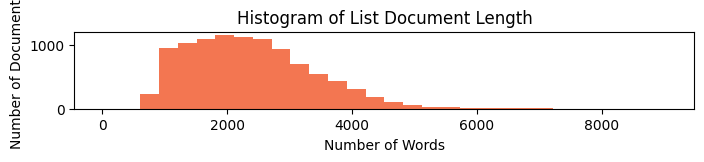

In [ ]:
plt.figure(figsize=(8, 1))
plt.hist(list_length, bins=30, color=sns.color_palette('rocket')[4])
plt.title("Histogram of List Document Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Documents")
plt.show()

In [ ]:
data

,text,generated
0,cars cars have been around since they became f...,0.0
1,transportation is a large necessity in most co...,0.0
2,americas love affair with its vehicles seems t...,0.0
3,how often do you ride in a car do you drive a ...,0.0
4,cars are a wonderful thing they are perhaps on...,0.0
...,...,...
9991,this argument of the face on mars been going o...,0.0
9992,what happen on mars in may one of our spacecra...,0.0
9993,the face on mars wasnt created by aliens in fa...,0.0
9994,years ago on mars nasa caught a picture of a h...,0.0


In [ ]:
#split data into Features and Labels
data = data.sample(frac=1, random_state=42)
X, y = data['text'], data['generated'].values

In [ ]:
#split into two set data (train & val)
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8, stratify=y, random_state=seed)
print(f'X_train shape:  {X_train.shape}')
print(f'y_train shape:  {y_train.shape}')
print(f'X_val shape:    {X_val.shape}')
print(f'y_val shape:    {y_val.shape}')

X_train shape:  (7996,)
y_train shape:  (7996,)
X_val shape:    (2000,)
y_val shape:    (2000,)


In [ ]:
#Construct Tagged Doccument
train_tagged = construct_tagged_document(X_train, y_train)
val_tagged = construct_tagged_document(X_val, y_val)
data_tagged = train_tagged + val_tagged
pd.DataFrame(data_tagged).head()

,words,tags
0,"[driving, car, has, its, ups, and, downs, to, ...","[0.0, 4947]"
1,"[striving, to, meet, challenges, in, life, com...","[0.0, 6908]"
2,"[in, this, argument, im, going, to, tell, you,...","[0.0, 9938]"
3,"[do, you, ever, sit, in, class, so, confused, ...","[0.0, 9107]"
4,"[think, about, how, many, times, week, we, get...","[0.0, 78]"


In [ ]:
#Build DOc2Vec Model
INPUT_DIM = 1000
EPOCHS = 20
MIN_COUNT = 0
RETRAIN = [True, False][  1 ]
cores = multiprocessing.cpu_count()

d2v=None
filename='Doc2Vec.d2v'

if os.path.isfile(filename) and RETRAIN == False:
    print('Read Model')
    d2v = Doc2Vec.load(filename)
else:
    print('Train Model...')
    d2v = Doc2Vec(dm=1, vector_size=INPUT_DIM,
                  negative=1, hs=0,
                  min_count=MIN_COUNT, workers=cores)
    d2v.build_vocab(data_tagged)
    d2v.train(data_tagged, total_examples=d2v.corpus_count, epochs=EPOCHS)
    d2v.save(filename)

vocab = len(d2v.dv)
print(f'Vocab: {vocab}')

Train Model...
Vocab: 9998


In [ ]:
#transform data into vector + reshaped data for tensorflow
X_train_vector, y_train_tag = d2v_vector(d2v, train_tagged)
X_train_reshaped, y_train_reshaped = transform_data(X_train_vector, y_train_tag)

X_val_vector, y_val_tag = d2v_vector(d2v, val_tagged)
X_val_reshaped, y_val_reshaped = transform_data(X_val_vector, y_val_tag)

print(f'X_train_reshaped shape : {X_train_reshaped.shape}')
print(f'y_train_reshaped shape : {y_train_reshaped.shape}')
print(f'X_val_reshaped shape : {X_val_reshaped.shape}')
print(f'y_val_reshaped shape : {y_val_reshaped.shape}')

X_train_reshaped shape : (7996, 1000, 1)
y_train_reshaped shape : (7996, 1)
X_val_reshaped shape : (2000, 1000, 1)
y_val_reshaped shape : (2000, 1)


In [ ]:
#init model BertTokenizer using BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
#Encode the data
X_train_encoded = encoded_data(tokenizer, X_train)
X_val_encoded = encoded_data(tokenizer, X_val)

#seperated input_id, attention_mask and create label as tensor
X_train_ids = X_train_encoded['input_ids']
X_train_mask = X_train_encoded['attention_mask']
y_train_tensor = torch.tensor(y_train)

X_val_ids = X_val_encoded['input_ids']
X_val_mask = X_val_encoded['attention_mask']
y_val_tensor = torch.tensor(y_val)

print(f'X_train_ids shape:    {X_train_ids.shape}')
print(f'X_train_mask shape:   {X_train_mask.shape}')
print(f'y_train_tensor shape: {y_train_tensor.shape}')
print(f'X_val_ids shape:      {X_val_ids.shape}')
print(f'X_val_mask shape:     {X_val_mask.shape}')
print(f'y_val_tensor shape:   {y_val_tensor.shape}')

KeyboardInterrupt: 

In [ ]:
#Create tensor dataset
dataset_train = TensorDataset(X_train_ids, X_train_mask, y_train_tensor)
dataset_val = TensorDataset(X_val_ids, X_val_mask, y_val_tensor)

print(len(dataset_train))
print(len(dataset_val))

7996
2000


In [ ]:
#check GPU
print('Use GPU') if tf.test.is_built_with_cuda() and tf.config.list_physical_devices('GPU') else print('Use CPU')

Use CPU


In [ ]:
#init params
experiments = []
unit = 50
d_rate = 0.1
a_rate = 1e-4
deep_epochs = 30
deep_size = 15
bert_epochs = 10
bert_size = 15

In [ ]:
#LSTM
lstm = Sequential(name='LSTM')
lstm.add(LSTM(unit, return_sequences=True))
lstm.add(Dropout(d_rate))
lstm.add(LSTM(unit, return_sequences=True))
lstm.add(Dropout(d_rate))
lstm.add(LSTM(unit, return_sequences=True))
lstm.add(Dropout(d_rate))
lstm.add(LSTM(unit))
lstm.add(Dropout(d_rate))
lstm.add(Dense(1, activation='sigmoid'))
lstm.build(input_shape=X_train_reshaped.shape)
lstm.compile(optimizer=Adam(learning_rate=a_rate), loss='binary_crossentropy', metrics=['accuracy'])
lstm.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (7996, 1000, 50)       │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (7996, 1000, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (7996, 1000, 50)       │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (7996, 1000, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (7996, 1000, 50)       │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (7996, 1000, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (7996, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (7996, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (7996, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training
checkpoint = ModelCheckpoint('LSTM.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
experiments.append(lstm.fit(X_train_reshaped, y_train_reshaped, validation_data=(X_val_reshaped, y_val_reshaped), epochs=deep_epochs, batch_size=deep_size, verbose=1, callbacks=[checkpoint]))
best_lstm = tf.keras.models.load_model("LSTM.h5")

534/534 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9768 - loss: 0.0675
Epoch 1: val_accuracy improved from -inf to 0.98450, saving model to LSTM.h5


534/534 ━━━━━━━━━━━━━━━━━━━━ 925s 2s/step - accuracy: 0.9768 - loss: 0.0675 - val_accuracy: 0.9845 - val_loss: 0.0474


In [ ]:
#evaluate
y_lstm_pred = best_lstm.predict(X_val_reshaped)
y_lstm_pred = np.round(y_lstm_pred).flatten()
print(classification_report(y_lstm_pred, y_val_reshaped))

63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 434ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1791
         1.0       0.93      0.92      0.93       209

    accuracy                           0.98      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.98      0.98      0.98      2000



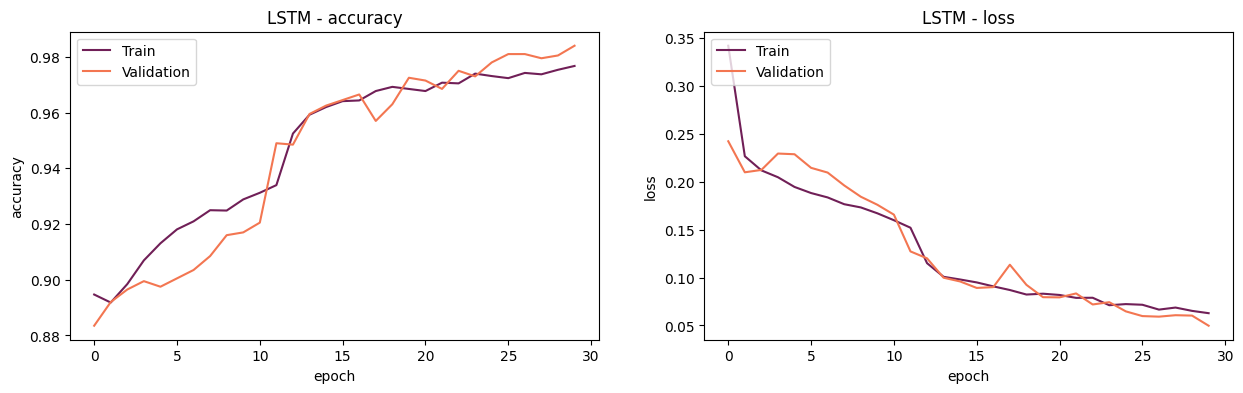

In [ ]:
#plot accuracy and loss
plt.figure(figsize=(15,4))
metrics_plot = ['accuracy', 'loss']
for i,metric in enumerate(metrics_plot):
  plt.subplot(1, 2, i+1)
  experiment = experiments[0]
  plt.plot(experiment.history[metric], color=sns.color_palette('rocket')[1])
  plt.plot(experiment.history[f'val_{metric}'], color=sns.color_palette('rocket')[4])
  plt.title(f'LSTM - {metric}')
  plt.ylabel(metric)
  plt.xlabel('epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
#GRU
gru = Sequential(name='GRU')
gru.add(GRU(unit, return_sequences=True))
gru.add(Dropout(d_rate))
gru.add(GRU(unit, return_sequences=True))
gru.add(Dropout(d_rate))
gru.add(GRU(unit, return_sequences=True))
gru.add(Dropout(d_rate))
gru.add(GRU(unit))
gru.add(Dropout(d_rate))
gru.add(Dense(1, activation='sigmoid'))
gru.build(input_shape=X_train_reshaped.shape)
gru.compile(optimizer=Adam(learning_rate=a_rate), loss='binary_crossentropy', metrics=['accuracy'])
gru.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (7996, 1000, 50)       │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (7996, 1000, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (7996, 1000, 50)       │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (7996, 1000, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (7996, 1000, 50)       │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (7996, 1000, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (7996, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (7996, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (7996, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,901 (210.55 KB)

 Trainable params: 53,901 (210.55 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training
checkpoint = ModelCheckpoint('GRU.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
experiments.append(gru.fit(X_train_reshaped, y_train_reshaped, validation_data=(X_val_reshaped, y_val_reshaped), epochs=deep_epochs, batch_size=deep_size, verbose=1, callbacks=[checkpoint]))
best_gru = tf.keras.models.load_model("GRU.h5")

In [ ]:
#evaluate
y_gru_pred = best_gru.predict(X_val_reshaped)
y_gru_pred = np.round(y_gru_pred).flatten()
print(classification_report(y_gru_pred, y_val_reshaped))

In [ ]:
#plot accuracy and loss
plt.figure(figsize=(15,4))
metrics_plot = ['accuracy', 'loss']
for i,metric in enumerate(metrics_plot):
  plt.subplot(1, 2, i+1)
  experiment = experiments[1]
  plt.plot(experiment.history[metric], color=sns.color_palette('rocket')[1])
  plt.plot(experiment.history[f'val_{metric}'], color=sns.color_palette('rocket')[4])
  plt.title(f'GRU - {metric}')
  plt.ylabel(metric)
  plt.xlabel('epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
#BI-LSTM
bilstm = Sequential(name='BI_LSTM')
bilstm.add(Bidirectional(LSTM(unit, return_sequences=True)))
bilstm.add(Dropout(d_rate))
bilstm.add(Bidirectional(LSTM(unit, return_sequences=True)))
bilstm.add(Dropout(d_rate))
bilstm.add(Bidirectional(LSTM(unit, return_sequences=True)))
bilstm.add(Dropout(d_rate))
bilstm.add(Bidirectional(LSTM(unit)))
bilstm.add(Dropout(d_rate))
bilstm.add(Dense(1, activation='sigmoid'))
bilstm.build(input_shape=X_train_reshaped.shape)
bilstm.compile(optimizer=Adam(learning_rate=a_rate), loss='binary_crossentropy', metrics=['accuracy'])
bilstm.summary()

In [ ]:
#training
checkpoint = ModelCheckpoint('BI_LSTM.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
experiments.append(bilstm.fit(X_train_reshaped, y_train_reshaped, validation_data=(X_val_reshaped, y_val_reshaped), epochs=deep_epochs, batch_size=deep_size, verbose=1, callbacks=[checkpoint]))
best_bilstm = tf.keras.saving.load_model("BI_LSTM.h5")

In [ ]:
#evaluate
y_bilstm_pred = best_bilstm.predict(X_val_reshaped)
y_bilstm_pred = np.round(y_bilstm_pred).flatten()
print(classification_report(y_bilstm_pred, y_val_reshaped))

In [ ]:
#plot accuracy and loss
plt.figure(figsize=(15,4))
metrics_plot = ['accuracy', 'loss']
for i,metric in enumerate(metrics_plot):
  plt.subplot(1, 2, i+1)
  experiment = experiments[2]
  plt.plot(experiment.history[metric], color=sns.color_palette('rocket')[1])
  plt.plot(experiment.history[f'val_{metric}'], color=sns.color_palette('rocket')[4])
  plt.title(f'BI-LSTM - {metric}')
  plt.ylabel(metric)
  plt.xlabel('epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
#BI-GRU
bigru = Sequential(name='BI_GRU')
bigru.add(Bidirectional(GRU(unit, return_sequences=True)))
bigru.add(Dropout(d_rate))
bigru.add(Bidirectional(GRU(unit, return_sequences=True)))
bigru.add(Dropout(d_rate))
bigru.add(Bidirectional(GRU(unit, return_sequences=True)))
bigru.add(Dropout(d_rate))
bigru.add(Bidirectional(GRU(unit)))
bigru.add(Dropout(d_rate))
bigru.add(Dense(1, activation='sigmoid'))
bigru.build(input_shape=X_train_reshaped.shape)
bigru.compile(optimizer=Adam(learning_rate=a_rate), loss='binary_crossentropy', metrics=['accuracy'])
bigru.summary()

In [ ]:
#training
checkpoint = ModelCheckpoint('BI_GRU.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
experiments.append(bigru.fit(X_train_reshaped, y_train_reshaped, validation_data=(X_val_reshaped, y_val_reshaped), epochs=deep_epochs, batch_size=deep_size, verbose=1, callbacks=[checkpoint]))
best_bigru = tf.keras.saving.load_model("BI_GRU.h5")

In [ ]:
#evaluate
y_bigru_pred = best_bigru.predict(X_val_reshaped)
y_bigru_pred = np.round(y_bigru_pred).flatten()
print(classification_report(y_bigru_pred, y_val_reshaped))

In [ ]:
#plot accuracy and loss
plt.figure(figsize=(15,4))
metrics_plot = ['accuracy', 'loss']
for i,metric in enumerate(metrics_plot):
  plt.subplot(1, 2, i+1)
  experiment = experiments[3]
  plt.plot(experiment.history[metric], color=sns.color_palette('rocket')[1])
  plt.plot(experiment.history[f'val_{metric}'], color=sns.color_palette('rocket')[4])
  plt.title(f'BI-GRU - {metric}')
  plt.ylabel(metric)
  plt.xlabel('epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
bert = BertClassifier.from_pretrained(bert, num_labels=2, output_attentions=False, output_hidden_states=False)

device = None
if torch.cuda.is_available():
    device = torch.device("cuda")
    bert.to(device)
else:
    device = torch.device("cpu")
print(f'\nDevice available: {device}')

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Device available: cuda


In [ ]:
#function for fine tuning model BERT
def bert_fit(dataloader_train, dataloader_val, epochs):
  history = []
  monitor_acc = 0
  for epoch in range(0, epochs):
    #initial stats
    total_loss_train, total_acc_train = 0, 0
    total_loss_val, total_acc_val = 0, 0
    y_pred_train, y_actual_train = [], []
    y_pred_val, y_actual_val = [], []
    print(f'Epoch {epoch+1}/{epochs}')

    format = '{n_fmt}/{total_fmt} [{bar}] {rate_fmt}{postfix}'

    #train with progress bar
    with tqdm(total=len(dataloader_train), bar_format=format) as progress:
      bert.train() #start training
      for batch_train in dataloader_train:
        bert.zero_grad()
        inputs_train = {
          'input_ids':      batch_train[0].to(device),
          'attention_mask': batch_train[1].to(device),
          'labels':         batch_train[2].to(device),
        }
        outputs_train = bert(**inputs_train)
        loss_train, logits_train = outputs_train[0], outputs_train[1]
        logits_train = logits_train.detach().cpu().tolist()
        label_train = inputs_train['labels'].cpu().tolist()
        total_loss_train += loss_train.item()

        y_pred_train.extend(logits_train)
        y_actual_train.extend(label_train)

        torch.nn.utils.clip_grad_norm_(bert.parameters(), 1.0)
        loss_train.backward()
        optimizer.step()
        scheduler.step()
        progress.update(1)

      bert.eval() #start validation
      for batch_val in dataloader_val:
        inputs_val = {
            'input_ids':      batch_val[0].to(device),
            'attention_mask': batch_val[1].to(device),
            'labels':         batch_val[2].to(device),
        }
        with torch.no_grad():
          outputs_val = bert(**inputs_val)
        loss_val, logits_val = outputs_val[0], outputs_val[1]
        logits_val = logits_val.detach().cpu().numpy()
        label_val = inputs_val['labels'].cpu().tolist()
        total_loss_val += loss_val.item()

        y_pred_val.extend(logits_val)
        y_actual_val.extend(label_val)

      #recalculte loss and acc
      total_loss_train = total_loss_train/len(dataloader_train)
      total_acc_train  = accuracy_score(np.argmax(y_pred_train, axis=1).tolist(), y_actual_train)
      total_loss_val   = total_loss_val/len(dataloader_val)
      total_acc_val    = accuracy_score(np.argmax(y_pred_val, axis=1).tolist(), y_actual_val)

      #keep history each epoch
      stats = {
          'epoch':        epoch+1,
          'loss':         total_loss_train/len(dataloader_train),
          'accuracy':     accuracy_score(np.argmax(y_pred_train, axis=1).tolist(), y_actual_train),
          'val_loss':     total_loss_val/len(dataloader_val),
          'val_accuracy': accuracy_score(np.argmax(y_pred_val, axis=1).tolist(), y_actual_val)
      }
      history.append(stats)

      #monitoring accuracy
      improvement = 'Not Improved'
      if total_acc_val > monitor_acc:
        monitor_acc = total_acc_val
        improvement = 'Improved'

      #save last model
      torch.save(bert.state_dict(), 'BERT.model')

      #display progress
      stats.pop('epoch')
      stats['monitoring'] = improvement
      progress.set_postfix(stats, refresh=False)
      progress.set_description(improvement)
      clean_memory()
  return history

#function for display layer of BERT
def bert_summary(params):
  summary = []
  for p in params:
    summary.append([p[0], str(tuple(p[1].size()))])
  summary.insert(4, ['='*55, '='*13])
  summary.insert(5, ['Transformer Layer', 'Shape'])
  summary.insert(6, ['='*55, '='*13])
  summary.insert(0, ['='*55, '='*13])
  summary.insert(0, ['Embedding Layer', 'shape'])
  summary.insert(0, ['='*55, '='*13])
  summary.insert(-4, ['='*55, '='*13])
  summary.insert(-4, ['Output Layer', 'shape'])
  summary.insert(-4, ['='*55, '='*13])
  print(f'Model: BERT')
  print(f'Total Parameters: {len(list(params))}')
  print(tabulate(summary, tablefmt='plain'))

In [ ]:
bert_summary(bert.named_parameters())

Model: BERT
Total Parameters: 0
=======================================================  =============
Embedding Layer                                          shape
=======================================================  =============
bert.embeddings.word_embeddings.weight                   (30522, 768)
bert.embeddings.position_embeddings.weight               (512, 768)
bert.embeddings.token_type_embeddings.weight             (2, 768)
bert.embeddings.LayerNorm.weight                         (768,)
=======================================================  =============
Transformer Layer                                        Shape
=======================================================  =============
bert.embeddings.LayerNorm.bias                           (768,)
bert.encoder.layer.0.attention.self.query.weight         (768, 768)
bert.encoder.layer.0.attention.self.query.bias           (768,)
bert.encoder.layer.0.attention.self.key.weight           (768, 768)
bert.encoder.layer.0.atten

In [ ]:
def encoded_data(tokenizer, texts):
    return tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )

In [ ]:
y_train_tensor = torch.tensor(y_train).long()
y_val_tensor = torch.tensor(y_val).long()

X_train_encoded = encoded_data(tokenizer, X_train)
X_val_encoded = encoded_data(tokenizer, X_val)

dataset_train = TensorDataset(X_train_encoded['input_ids'], X_train_encoded['attention_mask'], y_train_tensor)
dataset_val = TensorDataset(X_val_encoded['input_ids'], X_val_encoded['attention_mask'], y_val_tensor)

In [ ]:
#Create the Data Loaders & Optimizer & Scheduler
dataloader_train = DataLoader(dataset_train, sampler=RandomSampler(dataset_train), batch_size=bert_size)
dataloader_val = DataLoader(dataset_val, sampler=RandomSampler(dataset_val), batch_size=bert_size)
optimizer = AdamW(bert.parameters(), lr=a_rate)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=len(dataloader_train)*bert_epochs)

#Retraining model bert (fine tuning)
experiments.append(bert_fit(dataloader_train, dataloader_val, bert_epochs))

Epoch 1/10


534/534 [██████████]  1.49s/it, loss=0.000594, accuracy=0.904, val_loss=0.00248, val_accuracy=0.897, monitoring=Improved


Epoch 2/10


534/534 [██████████]  1.48s/it, loss=0.000628, accuracy=0.897, val_loss=0.00248, val_accuracy=0.897, monitoring=Not Improved


Epoch 3/10


...

534/534 [██████████]  1.49s/it, loss=0.000626, accuracy=0.897, val_loss=0.00248, val_accuracy=0.897, monitoring=Not Improved


Epoch 9/10


534/534 [██████████]  1.48s/it, loss=0.000628, accuracy=0.897, val_loss=0.00247, val_accuracy=0.897, monitoring=Not Improved


Epoch 10/10


534/534 [██████████]  1.49s/it, loss=0.000624, accuracy=0.897, val_loss=0.00247, val_accuracy=0.897, monitoring=Not Improved


In [ ]:
# Instantiate the model architecture
bert_eval = BertClassifier.from_pretrained("bert-base-uncased", num_labels=2)

# Load the trained weights
state_dict = torch.load("BERT.model")
bert_eval.load_state_dict(state_dict)
bert_eval.to(device)
y_pred_val, y_actual_val = [], []
bert_eval.eval()
for batch_val in dataloader_val:
  inputs_val = {
      'input_ids':      batch_val[0].to(device),
      'attention_mask': batch_val[1].to(device),
      'labels':         batch_val[2].to(device),
  }
  with torch.no_grad():
    outputs_val = bert_eval(**inputs_val)
  loss_val, logits_val = outputs_val[0], outputs_val[1]
  logits_val = logits_val.detach().cpu().numpy()
  label_val = inputs_val['labels'].cpu().tolist()

  y_pred_val.extend(logits_val)
  y_actual_val.extend(label_val)

print(classification_report(np.argmax(y_pred_val, axis=1).tolist(), y_actual_val))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


              precision    recall  f1-score   support

           0       1.00      0.90      0.95      2000
           1       0.00      0.00      0.00         0

    accuracy                           0.90      2000
   macro avg       0.50      0.45      0.47      2000
weighted avg       1.00      0.90      0.95      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


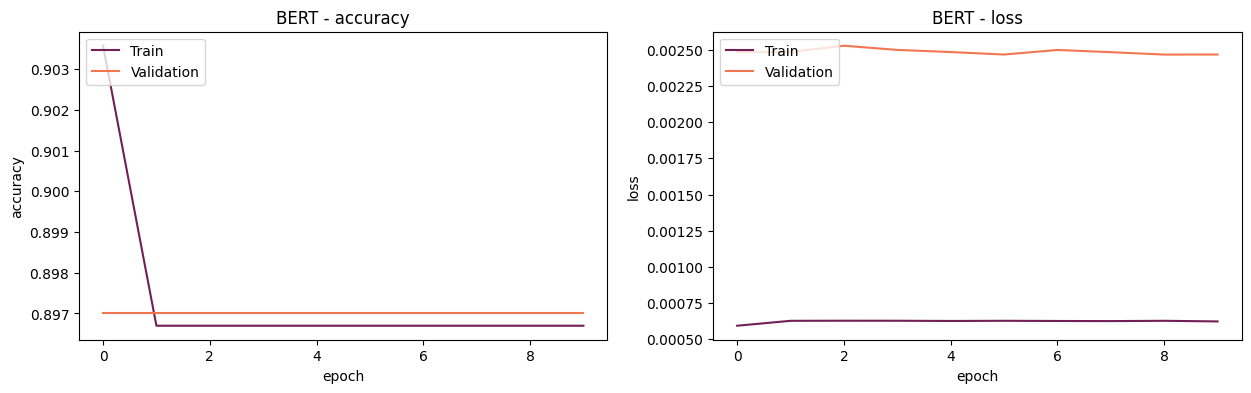

In [ ]:
#plot accuracy and loss
plt.figure(figsize=(15,4))
metrics_plot = ['accuracy', 'loss']
for i,metric in enumerate(metrics_plot):
  plt.subplot(1, 2, i+1)
  experiment = experiments[-1]
  plt.plot([item[metric] for item in experiment], color=sns.color_palette('rocket')[1])
  plt.plot([item[f'val_{metric}'] for item in experiment], color=sns.color_palette('rocket')[4])
  plt.title(f'BERT - {metric}')
  plt.ylabel(metric)
  plt.xlabel('epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
#show time execution
print(round((time.time() - start_time)/60, 3), 'min')

224.232 min
